# Chapter 8 — Visualization as a Learning Tool

> **Prerequisites:** ch001–ch007
>
> **You will learn:**
> - When visualization clarifies thinking vs when it creates false confidence
> - The grammar of a mathematical plot: what each element should communicate
> - How to choose the right visualization for different mathematical structures
> - How to build visualizations that invite exploration, not just display results
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Visualization is not decoration. In mathematical work, a good plot can reveal structure that would take pages of algebra to establish — and a bad plot can hide errors that a table of numbers would expose immediately.

The key distinction:

**Visualization as a tool** — you generate a plot in order to discover something. You do not know what you will see. The plot is part of the thinking.

**Visualization as a product** — you make a plot to show others something you already know. The plot is communication.

This chapter is about the first kind. It covers what to plot, how to plot it, what to look for, and — critically — when a plot is misleading.

**Common misconception:** If something looks smooth in a plot, it is smooth.

This is false. Insufficient resolution, poor axis scaling, or data sorted in a misleading way can all make discontinuous, noisy, or pathological data look well-behaved. The cure is cross-checking: if a plot claims something surprising, verify it with a different representation.

## 2. Intuition & Mental Models

**Physical analogy:** Medical imaging. An MRI scan does not show you the patient directly — it shows you a mathematical reconstruction from magnetic resonance signals. The reconstruction involves choices (resolution, contrast, slice plane) that can emphasize some features and hide others. A radiologist reads scans with awareness of what the reconstruction process can hide. Mathematical visualization requires the same awareness.

**Computational analogy:** A stack trace vs a flame graph. A raw stack trace is a list of function calls — complete but hard to read. A flame graph is a visualization that makes the same information spatially accessible, revealing which functions dominate runtime at a glance. The information content is the same; the cognitive accessibility is entirely different. Good visualization is the flame graph, not the stack trace.

Recall from ch003 *(Abstraction and Modeling)*: the three-domain plot (bank/bacteria/decay) made the shared structure visible in a way the equations alone did not. That is the learning-tool use of visualization.

## 3. Visualization

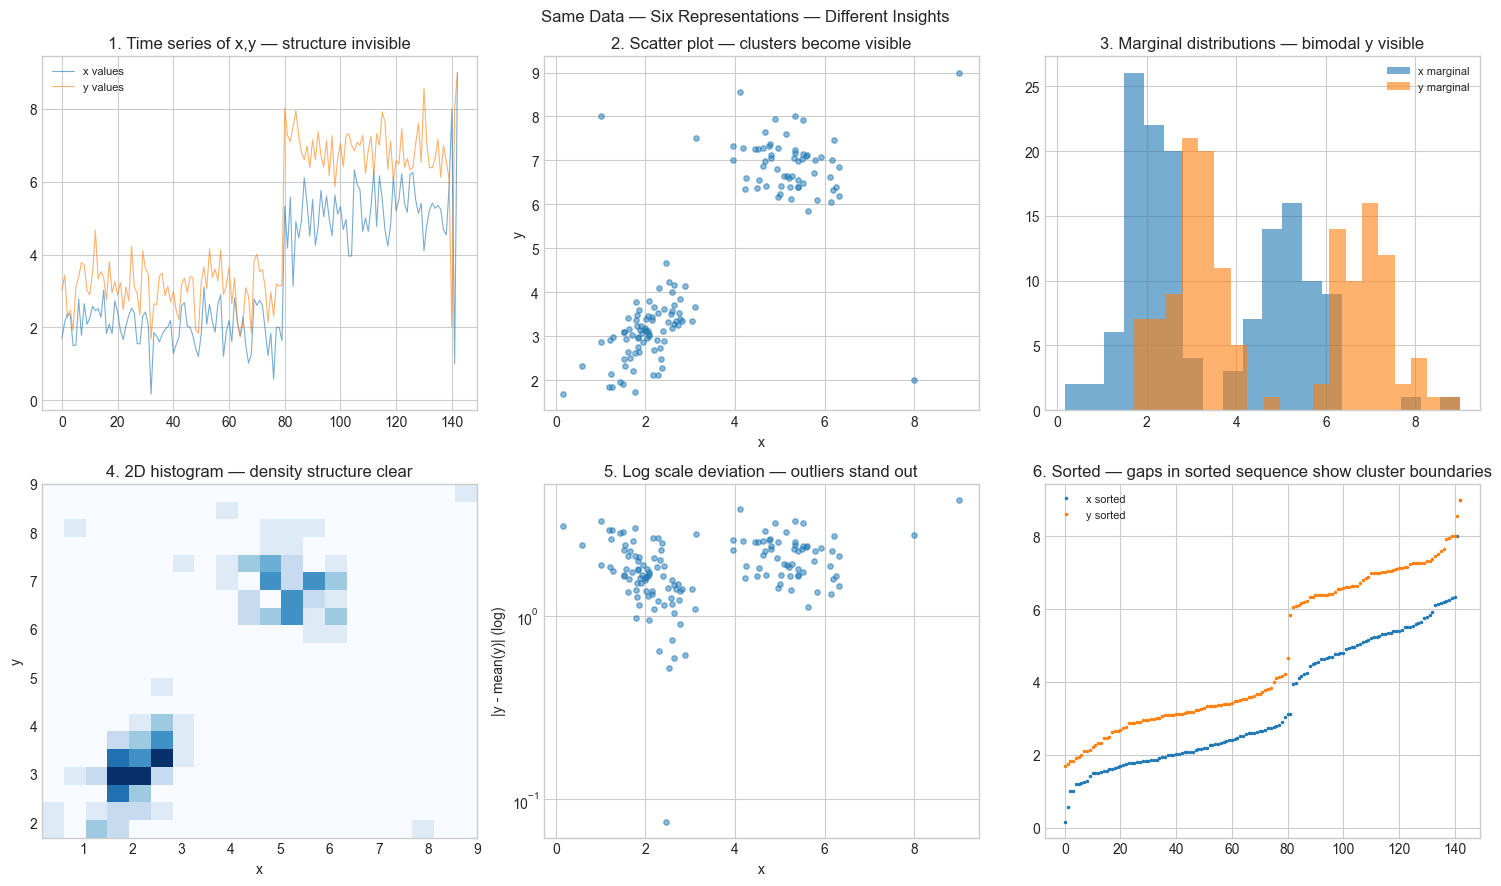

Representation 1 hides everything.
Representation 2 shows the clusters.
Representation 4 shows their density structure.
No single representation shows everything. Use multiple.


In [1]:
# --- Visualization: Same data, five representations — what each reveals ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(77)

# Generate data with hidden structure: two clusters + outliers
cluster1 = np.random.multivariate_normal([2, 3], [[0.3, 0.2], [0.2, 0.4]], 80)
cluster2 = np.random.multivariate_normal([5, 7], [[0.5, -0.1], [-0.1, 0.3]], 60)
outliers = np.array([[8, 2], [1, 8], [9, 9]])
data = np.vstack([cluster1, cluster2, outliers])
x, y = data[:, 0], data[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Bad: plot x and y separately as time series (wrong representation)
axes[0,0].plot(x, alpha=0.6, linewidth=0.8, label='x values')
axes[0,0].plot(y, alpha=0.6, linewidth=0.8, label='y values')
axes[0,0].set_title('1. Time series of x,y — structure invisible')
axes[0,0].legend(fontsize=8)

# 2. Better: scatter plot
axes[0,1].scatter(x, y, alpha=0.5, s=15)
axes[0,1].set_title('2. Scatter plot — clusters become visible')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')

# 3. Marginal histograms
axes[0,2].hist(x, bins=20, alpha=0.6, label='x marginal')
axes[0,2].hist(y, bins=20, alpha=0.6, label='y marginal')
axes[0,2].set_title('3. Marginal distributions — bimodal y visible')
axes[0,2].legend(fontsize=8)

# 4. 2D histogram (density)
axes[1,0].hist2d(x, y, bins=20, cmap='Blues')
axes[1,0].set_title('4. 2D histogram — density structure clear')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')

# 5. Log scale on y — reveals outliers differently
axes[1,1].scatter(x, np.abs(y - y.mean()), alpha=0.5, s=15)
axes[1,1].set_yscale('log')
axes[1,1].set_title('5. Log scale deviation — outliers stand out')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('|y - mean(y)| (log)')

# 6. Sorted scatter — reveals rank structure
sort_idx = np.argsort(x)
axes[1,2].plot(np.arange(len(x)), x[sort_idx], '.', markersize=3, label='x sorted')
axes[1,2].plot(np.arange(len(y)), np.sort(y), '.', markersize=3, label='y sorted')
axes[1,2].set_title('6. Sorted — gaps in sorted sequence show cluster boundaries')
axes[1,2].legend(fontsize=8)

plt.suptitle('Same Data — Six Representations — Different Insights', fontsize=12)
plt.tight_layout()
plt.show()

print("Representation 1 hides everything.")
print("Representation 2 shows the clusters.")
print("Representation 4 shows their density structure.")
print("No single representation shows everything. Use multiple.")

## 4. Mathematical Formulation

A visualization is a **mapping** from a mathematical object to a visual representation. The choice of mapping determines what information is preserved, amplified, or destroyed.

**Information-preserving mappings:** The scatter plot of $(x_i, y_i)$ pairs preserves joint structure. The marginal histogram of $x_i$ preserves the distribution of $x$ but destroys information about its relationship with $y$.

**Scale transformations:** Applying $\log$ to an axis is a bijection on positive values. It preserves all information but *reweights* it — equal visual spacing corresponds to equal multiplicative differences, not additive ones. This makes power laws and exponential growth appear linear.

**The plotting choices that encode mathematical claims:**
- Linear scale: equal spacing = equal additive difference
- Log scale: equal spacing = equal multiplicative ratio
- Log-log scale: power law $y = ax^b$ appears as a line with slope $b$
- Semi-log (log y): exponential $y = ae^{bx}$ appears as a line with slope $b$

Every scale choice is a mathematical claim about the structure of the data.

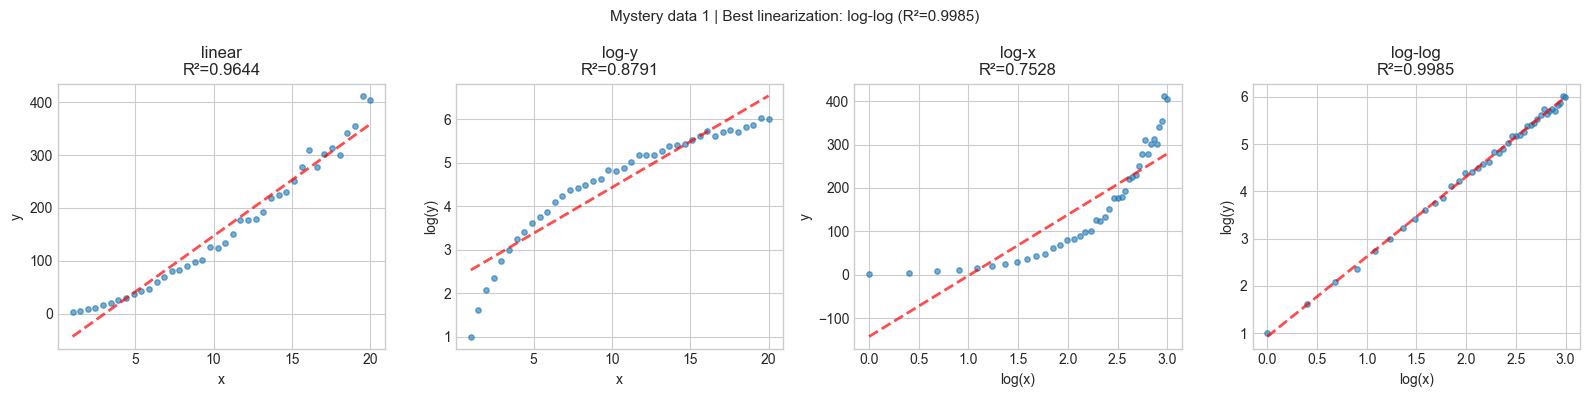

Suggested structure: power law (y = ax^b)


In [2]:
# --- Implementation: Smart plot selector ---
# Given data, automatically suggest the most informative scale.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def smart_plot(x, y, title='', xlabel='x', ylabel='y'):
    """
    Plot (x,y) on four scales and report which linearizes the relationship best.
    Helps identify the mathematical structure of data.
    """
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    valid = (x > 0) & (y > 0)
    
    def r_squared(xv, yv):
        coeffs = np.polyfit(xv, yv, 1)
        yp = np.polyval(coeffs, xv)
        ss_res = np.sum((yv - yp)**2)
        ss_tot = np.sum((yv - yv.mean())**2)
        return 1 - ss_res / ss_tot if ss_tot > 0 else 0
    
    scales = [
        ('linear',  x,            y,            'x',        'y'),
        ('log-y',   x[valid],     np.log(y[valid]), 'x',    'log(y)'),
        ('log-x',   np.log(x[valid]), y[valid],  'log(x)', 'y'),
        ('log-log', np.log(x[valid]), np.log(y[valid]), 'log(x)', 'log(y)'),
    ]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    best_r2, best_name = -np.inf, ''
    
    for ax, (name, xp, yp, xl, yl) in zip(axes, scales):
        r2 = r_squared(xp, yp)
        ax.scatter(xp, yp, s=15, alpha=0.6)
        coeffs = np.polyfit(xp, yp, 1)
        ax.plot(xp, np.polyval(coeffs, xp), 'r--', linewidth=2, alpha=0.7)
        ax.set_title(f'{name}\nR²={r2:.4f}')
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        if r2 > best_r2: best_r2, best_name = r2, name
    
    plt.suptitle(f'{title} | Best linearization: {best_name} (R²={best_r2:.4f})', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    structure = {'linear': 'linear (y = ax + b)',
                 'log-y': 'exponential (y = ae^bx)',
                 'log-x': 'logarithmic (y = a·log(x) + b)',
                 'log-log': 'power law (y = ax^b)'}.get(best_name, 'unknown')
    print(f"Suggested structure: {structure}")

# Test on known structures
np.random.seed(3)
t = np.linspace(1, 20, 40)
noise = lambda: 0.05 * np.random.randn(len(t))

smart_plot(t, 2.5 * t**1.7 * (1 + noise()), title='Mystery data 1')

## 5-6. Implementation & Experiments

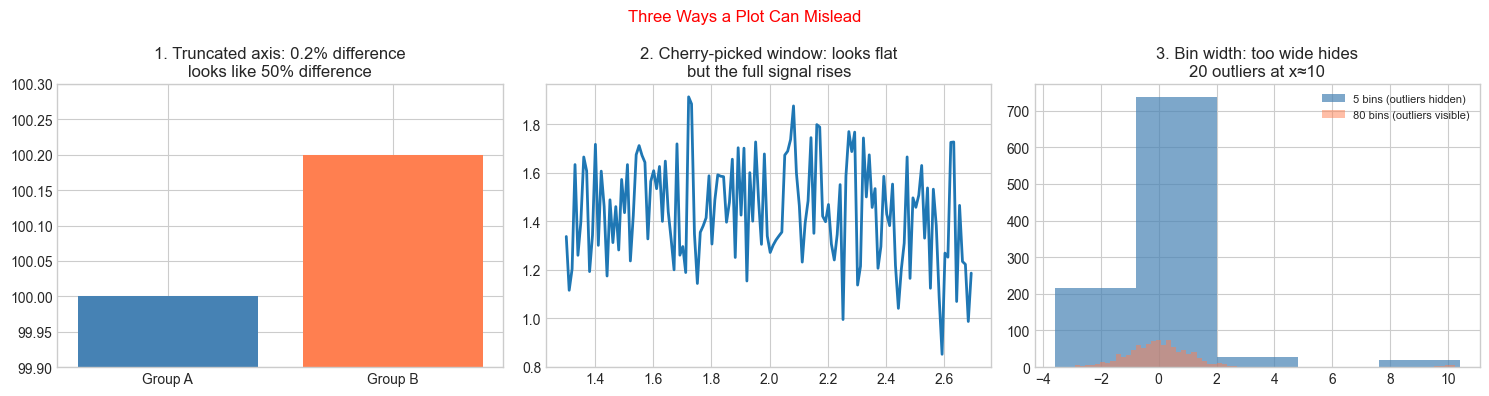

Defence: always start axes at 0 for bar charts, show full data range,
and inspect multiple bin widths for histograms.


In [3]:
# --- Experiment: Misleading visualizations ---
# Demonstrates three common ways plots lie.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(9)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Truncated y-axis: tiny difference looks huge
x = ['Group A', 'Group B']
y = [100.0, 100.2]
axes[0].bar(x, y, color=['steelblue', 'coral'])
axes[0].set_ylim(99.9, 100.3)
axes[0].set_title('1. Truncated axis: 0.2% difference\nlooks like 50% difference')

# 2. Cherry-picked range: trend depends entirely on window
t_full = np.linspace(0, 10, 1000)
y_full = np.sin(t_full) + 0.3 * t_full + 0.2 * np.random.randn(1000)
# Cherry-pick a range that looks flat
mask = (t_full >= 1.3) & (t_full <= 2.7)
axes[1].plot(t_full[mask], y_full[mask], linewidth=2)
axes[1].set_title('2. Cherry-picked window: looks flat\nbut the full signal rises')

# 3. Oversmoothing: outliers hidden by too-wide bins
data = np.concatenate([np.random.normal(0, 1, 980), np.random.normal(10, 0.3, 20)])
axes[2].hist(data, bins=5, alpha=0.7, color='steelblue', label='5 bins (outliers hidden)')
axes[2].hist(data, bins=80, alpha=0.5, color='coral', label='80 bins (outliers visible)')
axes[2].set_title('3. Bin width: too wide hides\n20 outliers at x≈10')
axes[2].legend(fontsize=8)

plt.suptitle('Three Ways a Plot Can Mislead', fontsize=12, color='red')
plt.tight_layout()
plt.show()

print("Defence: always start axes at 0 for bar charts, show full data range,")
print("and inspect multiple bin widths for histograms.")

## 7. Exercises

**Easy 1.** Plot the function $f(x) = x^3 - 3x$ on three different x-ranges: [-5,5], [-1.5,1.5], and [-0.1,0.1]. What features are visible in each range and invisible in the others? *(Expected: three subplots with commentary)*

**Easy 2.** Use `smart_plot` on the dataset: `x = np.arange(1, 50)`, `y = np.log(x) + 0.1*np.random.randn(49)`. What structure does it identify? Is that correct? *(Expected: logarithmic structure identified)*

**Medium 1.** The `smart_plot` function uses R² to select the best linearization. But R² can be high for a bad fit if the data has a strong trend. Add a residual plot (observed minus predicted) for each scale to the output, and update the selection criterion to prefer scales where the residuals look random (not structured). *(Hint: measure the autocorrelation of residuals)*

**Medium 2.** Anscombe's quartet is a set of four datasets with nearly identical summary statistics but completely different visual structures. Look up the four datasets, load them, and create a 2×4 grid showing (a) summary stats as a table, (b) the scatter plots. Explain why visualization catches what statistics misses.

**Hard.** Build an interactive parameter explorer: for a function `f(x; a, b, c) = a·sin(b·x + c)`, create a visualization that shows the function and updates in real-time as parameters change. Use `matplotlib.widgets.Slider` for the three parameters. Include: the function plot, its derivative (computed numerically), and the period (2π/b) displayed as a title. *(Challenge: add a fourth slider for noise level and show how the derivative becomes less reliable as noise increases)*

## 8. Mini Project

**Visualization Audit**: Take the five plots already generated in chapters 1–7 of this book. For each, identify: (1) what mathematical claim the visualization supports, (2) what it hides, (3) one misleading feature if any, and (4) one alternative visualization that would complement it.

In [4]:
# --- Mini Project: Visualization Audit Tool ---
# Build a checklist validator for mathematical plots.

def audit_visualization(description, has_axis_labels, starts_at_zero_if_bar,
                         shows_uncertainty, log_scale_justified, alternative_tried):
    """
    Run a checklist audit on a described visualization.
    Returns a score and recommendations.
    """
    checklist = {
        'Axis labels present':         has_axis_labels,
        'Bar chart starts at 0':        has_axis_labels and starts_at_zero_if_bar,
        'Uncertainty shown':            shows_uncertainty,
        'Log scale use justified':      log_scale_justified,
        'Alternative representation tried': alternative_tried,
    }
    score = sum(checklist.values())
    print(f"\nVisualization audit: '{description}'")
    print(f"Score: {score}/{len(checklist)}")
    for item, passed in checklist.items():
        print(f"  {'✓' if passed else '✗'}  {item}")
    if score < 3:
        print("  → Needs improvement before using as evidence.")
    elif score < 5:
        print("  → Adequate for exploration; improve before publication.")
    else:
        print("  → Strong visualization.")

# Audit some of our earlier plots
audit_visualization(
    description='ch001: Runtime loop vs formula bar comparison',
    has_axis_labels=True,
    starts_at_zero_if_bar=False,  # y-axis was truncated for log scale
    shows_uncertainty=False,
    log_scale_justified=True,  # runtime spans multiple orders of magnitude
    alternative_tried=False
)

audit_visualization(
    description='ch007: Insertion sort runtime with mean ± 1 std',
    has_axis_labels=True,
    starts_at_zero_if_bar=True,
    shows_uncertainty=True,
    log_scale_justified=True,
    alternative_tried=True
)


Visualization audit: 'ch001: Runtime loop vs formula bar comparison'
Score: 2/5
  ✓  Axis labels present
  ✗  Bar chart starts at 0
  ✗  Uncertainty shown
  ✓  Log scale use justified
  ✗  Alternative representation tried
  → Needs improvement before using as evidence.

Visualization audit: 'ch007: Insertion sort runtime with mean ± 1 std'
Score: 5/5
  ✓  Axis labels present
  ✓  Bar chart starts at 0
  ✓  Uncertainty shown
  ✓  Log scale use justified
  ✓  Alternative representation tried
  → Strong visualization.


## 9. Chapter Summary & Connections

- Visualization is a tool for thinking, not just for communicating — plots that invite exploration are more valuable than plots that display conclusions
- Axis scale choices are mathematical claims: linear scale claims additive structure, log scale claims multiplicative structure
- A good visualization requires multiple representations of the same data — each reveals different structure
- Three common ways plots mislead: truncated axes, cherry-picked ranges, and inappropriate bin widths

**Forward:** The smart plot selector built here is a primitive version of the exploratory data analysis tools in ch274 — Visualization of Data. The scale-selection methodology (which linearization fits best?) anticipates ch290 — Information Theory, where the right representation of data is formalized via entropy.

**Backward:** The multiple-representation principle reinforces ch003 *(Abstraction and Modeling)*: no single model captures everything, and no single visualization captures everything — you need multiple views to triangulate truth.